In [4]:
import pandas as pd
import numpy as np

file = "DF_FINAL.xlsx"
df_final = pd.read_excel(file)

df_final["timestamp"] = pd.to_datetime(
    df_final["timestamp"],
    dayfirst=True,
    errors="coerce"
)

# Extraer fecha, día de semana y hora
df_final["fecha"] = df_final["timestamp"].dt.date
df_final["dia_semana"] = df_final["timestamp"].dt.day_name(locale="es_ES")  # nombres en español
df_final["hora"] = df_final["timestamp"].dt.hour

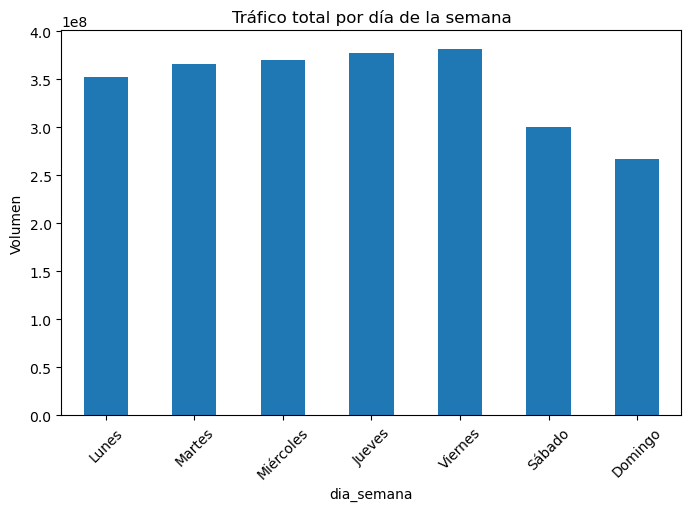

In [5]:
import matplotlib.pyplot as plt
import os

#trafico_semana = df_final.drop(columns=["timestamp", "fecha", "hora", "dia_semana"]).sum(axis=1).groupby(df_final["dia_semana"]).sum()

# 1. Definir columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas que empiezan por "AEMET"
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir todas las columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# 4. Calcular tráfico total por día de la semana
trafico_semana = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["dia_semana"])
    .sum()
)
trafico_semana = trafico_semana.reindex(["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"])

# 5. Crear carpeta para los gráficos (si no existe)
os.makedirs("Graficos", exist_ok=True)

# 6. Dibujar el gráfico
plt.figure(figsize=(8,5))
trafico_semana.plot(kind="bar")
plt.title("Tráfico total por día de la semana")
plt.ylabel("Volumen")
plt.xticks(rotation=45)

# 7. Guardar el gráfico en la carpeta Graficos
plt.savefig("Graficos/trafico_total_por_dia_semana.png", dpi=300, bbox_inches="tight")

# 8. Mostrar el gráfico
plt.show()

,Hora,Volumen promedio
0,0,38621.977291
1,1,27711.256852
2,2,19861.521535
3,3,15976.575568
4,4,15909.168363
5,5,25807.241973
6,6,53999.645262
7,7,87320.665623
8,8,100799.440094
9,9,100929.920908


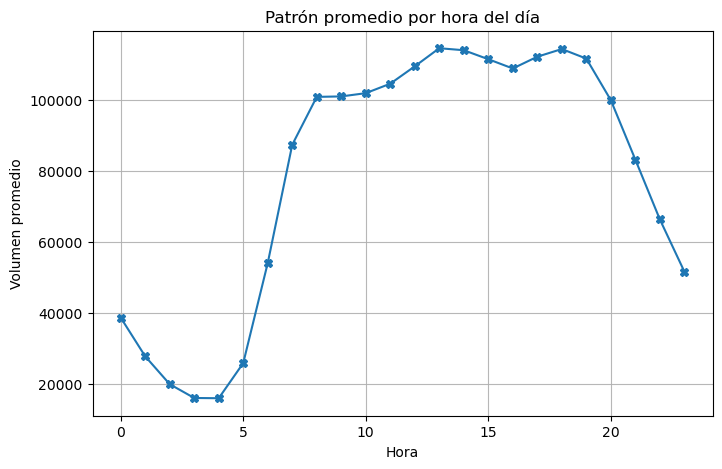

In [6]:
from IPython.display import display

# 1. Definir columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas que empiezan por "AEMET"
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir todas las columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

trafico_hora = df_final.drop(columns=columnas_excluir).sum(axis=1).groupby(df_final["hora"]).mean()

# 5. Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

# 6. Dibujar el gráfico
plt.figure(figsize=(8,5))
trafico_hora.plot(kind="line", marker="X")
plt.title("Patrón promedio por hora del día")
plt.xlabel("Hora")
plt.ylabel("Volumen promedio")
plt.grid(True, linestyle="-", alpha=0.91)

tabla_trafico_hora = pd.DataFrame({
    "Hora": trafico_hora.index,
    "Volumen promedio": trafico_hora.values
})

tabla_trafico_hora = tabla_trafico_hora.reset_index(drop=True)

display(tabla_trafico_hora)

# 7. Guardar el gráfico en PNG
plt.savefig(
    "Graficos/patron_promedio_trafico_por_hora.png",
    dpi=300,
    bbox_inches="tight"
)

# 8. Mostrar el gráfico
plt.show()

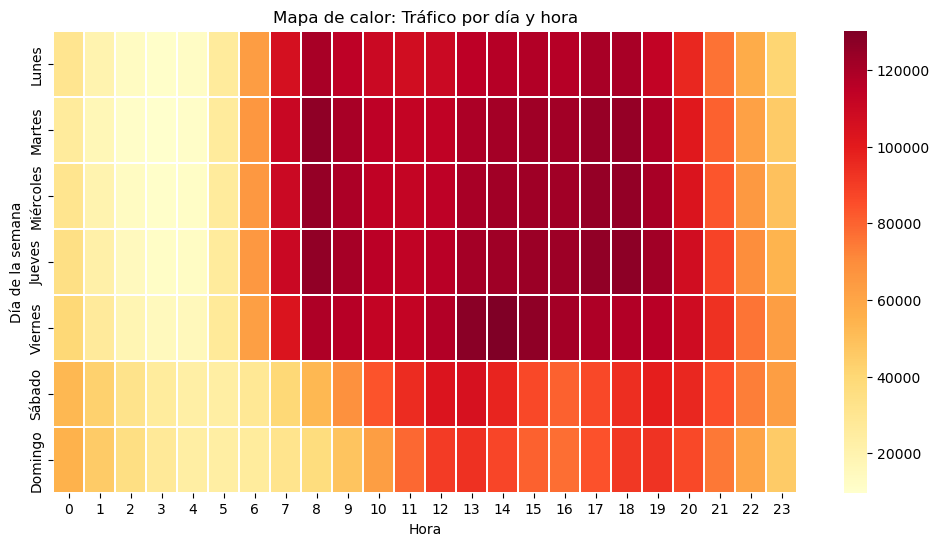

In [7]:
import seaborn as sns

# 1. Definir columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas que empiezan por "AEMET"
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir todas las columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

trafico_dia_hora = df_final.drop(columns=columnas_excluir).sum(axis=1)
pivot = pd.DataFrame({
    "hora": df_final["hora"],
    "dia_semana": df_final["dia_semana"],
    "trafico": trafico_dia_hora
})
tabla = pivot.groupby(["dia_semana","hora"]).mean().reset_index()
# Reordenar días
dias_orden = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
tabla["dia_semana"] = pd.Categorical(tabla["dia_semana"], categories=dias_orden, ordered=True)

heatmap_data = tabla.pivot(index="dia_semana", columns="hora", values="trafico")
# 6. Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

# 7. Dibujar el heatmap
plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=False
)

plt.title("Mapa de calor: Tráfico por día y hora")
plt.ylabel("Día de la semana")
plt.xlabel("Hora")

# 8. Guardar el gráfico en PNG
plt.savefig(
    "Graficos/mapa_calor_trafico_dia_hora.png",
    dpi=300,
    bbox_inches="tight"
)

# 9. Mostrar el gráfico
plt.show()

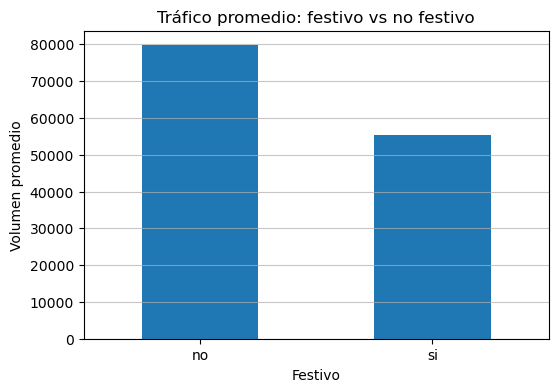

In [8]:
import matplotlib.pyplot as plt

# 1. Columnas a excluir 
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Columnas AEMET
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# 4. Sumar tráfico total por fila y agrupar por festivo / no festivo
trafico_festivo = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["festivo"])
    .mean()
)

# 5. Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

# 6. Gráfico de barras
plt.figure(figsize=(6,4))
trafico_festivo.plot(kind="bar")

plt.title("Tráfico promedio: festivo vs no festivo")
plt.xlabel("Festivo")
plt.ylabel("Volumen promedio")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="-", alpha=0.7)

# 7. Guardar el gráfico en PNG
plt.savefig(
    "Graficos/trafico_promedio_festivo_vs_no_festivo.png",
    dpi=300,
    bbox_inches="tight"
)

# 8. Mostrar el gráfico
plt.show()

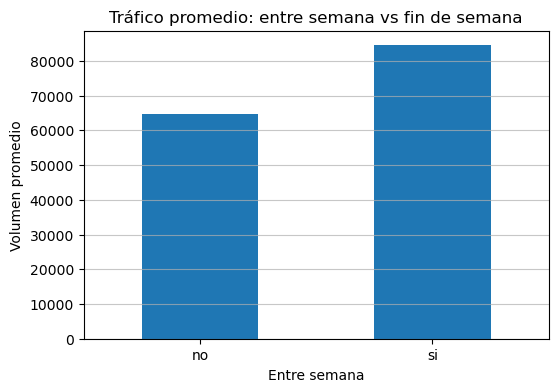

In [9]:
import matplotlib.pyplot as plt

# 1. Columnas a excluir 
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Columnas AEMET
columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]

# 3. Unir columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# 4. Sumar tráfico total por fila y agrupar por festivo / no festivo
trafico_festivo = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["entre semana"])
    .mean()
)

# 5. Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

# 6. Gráfico de barras
plt.figure(figsize=(6,4))
trafico_festivo.plot(kind="bar")

plt.title("Tráfico promedio: entre semana vs fin de semana")
plt.xlabel("Entre semana")
plt.ylabel("Volumen promedio")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="-", alpha=0.7)
# 7. Guardar el gráfico en PNG
plt.savefig(
    "Graficos/trafico_promedio_entre_semana_vs_findes.png",
    dpi=300,
    bbox_inches="tight"
)

# 8. Mostrar el gráfico
plt.show()


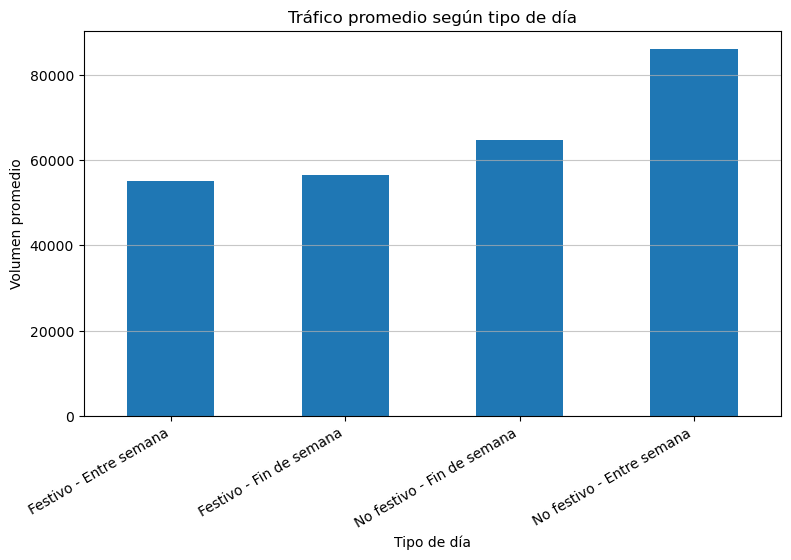

In [10]:
df_final["tipo_dia"] = (
    df_final["festivo"].map({"si": "Festivo", "no": "No festivo"})
    + " - " +
    df_final["entre semana"].map({"si": "Entre semana", "no": "Fin de semana"})
)

# Columnas a excluir
columnas_excluir_fijas = [
    "timestamp", "fecha", "hora", "dia_semana",
    "entre semana", "festivo", "tipo_dia"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# Tráfico promedio por tipo de día
trafico_tipo_dia = (
    df_final
    .drop(columns=columnas_excluir)
    .sum(axis=1)
    .groupby(df_final["tipo_dia"])
    .mean()
    .sort_values()
)

# Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

# Gráfico de barras
plt.figure(figsize=(9,5))
trafico_tipo_dia.plot(kind="bar")

plt.title("Tráfico promedio según tipo de día")
plt.xlabel("Tipo de día")
plt.ylabel("Volumen promedio")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.7)

# Guardar el gráfico en PNG
plt.savefig(
    "Graficos/trafico_promedio_segun_tipo_dia.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar
plt.show()


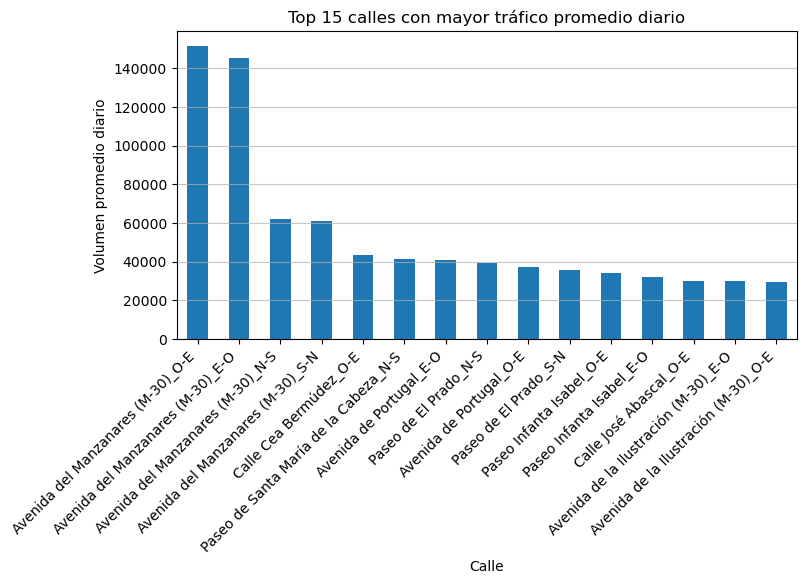

In [11]:
columnas_trafico = [
    col for col in df_final.columns
    if col not in columnas_excluir
]

trafico_diario = (
    df_final
    .groupby("fecha")[columnas_trafico]
    .sum()
)

trafico_medio_calle = trafico_diario.mean()

top_15 = trafico_medio_calle.sort_values(ascending=False).head(15)

# Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

# Gráfico de barras
plt.figure(figsize=(8,4))
top_15.plot(kind="bar")

plt.title("Top 15 calles con mayor tráfico promedio diario")
plt.xlabel("Calle")
plt.ylabel("Volumen promedio diario")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.7)

# Guardar el gráfico en PNG
plt.savefig(
    "Graficos/top_15_calles_trafico_promedio_diario.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar
plt.show()


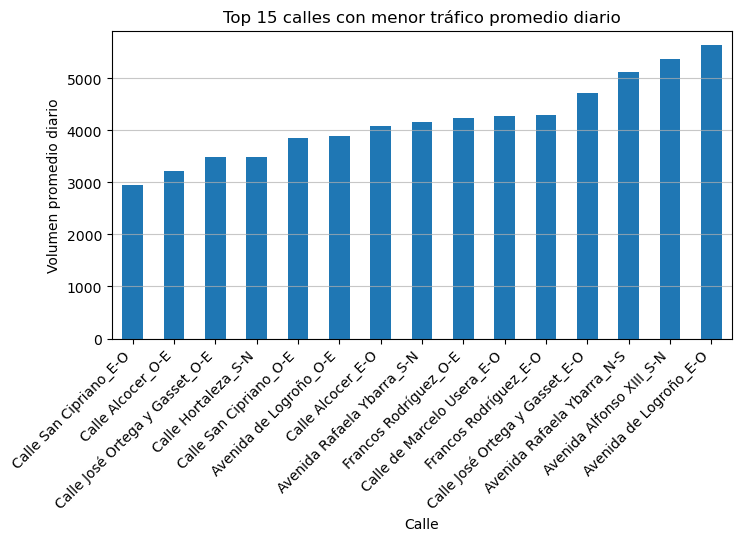

In [12]:
bottom_15 = trafico_medio_calle.sort_values(ascending=True).head(15)

# Gráfico de barras
plt.figure(figsize=(8,4))
bottom_15.plot(kind="bar")
plt.title("Top 15 calles con menor tráfico promedio diario")
plt.xlabel("Calle")
plt.ylabel("Volumen promedio diario")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.7)

# Guardar el gráfico en PNG
plt.savefig(
    "Graficos/bottom_15_calles_trafico_promedio_diario.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar
plt.show()

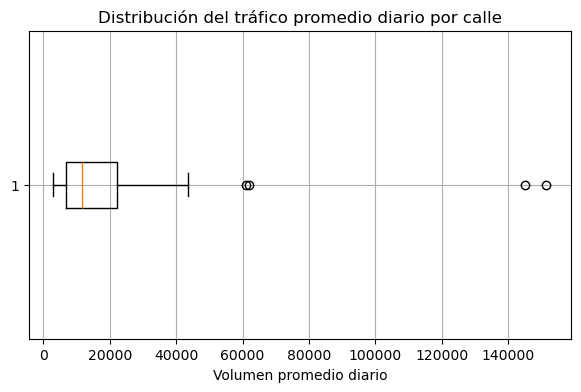

In [13]:
# Gráfico boxplot
plt.figure(figsize=(7,4))
plt.boxplot(trafico_medio_calle.values, vert=False)
plt.title("Distribución del tráfico promedio diario por calle")
plt.xlabel("Volumen promedio diario")
plt.grid(True)

# Guardar el gráfico en PNG
plt.savefig(
    "Graficos/distribucion_trafico_promedio_diario_por_calle.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar
plt.show()


In [14]:
Q1 = trafico_medio_calle.quantile(0.25)
mediana = trafico_medio_calle.quantile(0.50)
Q3 = trafico_medio_calle.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = trafico_medio_calle[
    (trafico_medio_calle < limite_inferior) |
    (trafico_medio_calle > limite_superior)
]

outliers.sort_values(ascending=False).head(5)

resumen_boxplot = {
    "Q1": Q1,
    "Mediana": mediana,
    "Q3": Q3,
    "IQR": IQR,
    "Límite inferior": limite_inferior,
    "Límite superior": limite_superior,
    "Nº de calles": len(trafico_medio_calle),
    "Nº de outliers": len(outliers)
}

for k, v in resumen_boxplot.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")


Q1: 6811.74
Mediana: 11594.96
Q3: 22042.77
IQR: 15231.04
Límite inferior: -16034.82
Límite superior: 44889.33
Nº de calles: 104
Nº de outliers: 4


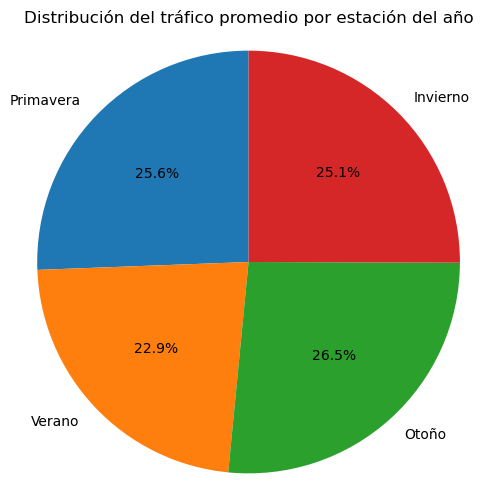

In [15]:
def asignar_estacion(fecha):
    dia = fecha.day
    mes = fecha.month

    if (mes == 3 and dia >= 20) or (mes in [4, 5]) or (mes == 6 and dia < 21):
        return "Primavera"
    elif (mes == 6 and dia >= 21) or (mes in [7, 8]) or (mes == 9 and dia < 22):
        return "Verano"
    elif (mes == 9 and dia >= 22) or (mes in [10, 11]) or (mes == 12 and dia < 21):
        return "Otoño"
    else:
        # Invierno: del 21 de diciembre al 20 de marzo
        return "Invierno"

df_final["estacion"] = df_final["fecha"].apply(asignar_estacion)

# Columnas a excluir
columnas_excluir_fijas = [
    "timestamp", "fecha", "hora", "dia_semana",
    "entre semana", "festivo", "estacion"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

columnas_trafico = [
    col for col in df_final.select_dtypes(include="number").columns
    if col not in ["hora"]
]

df_final["trafico_total"] = df_final[columnas_trafico].sum(axis=1)

trafico_estacion = (
    df_final
    .groupby("estacion")["trafico_total"]
    .mean()
    .reindex(["Primavera", "Verano", "Otoño", "Invierno"])
)

plt.figure(figsize=(6,6))
plt.pie(
    trafico_estacion,
    labels=trafico_estacion.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Distribución del tráfico promedio por estación del año")
plt.axis("equal")  # para que sea circular
# Guardar el gráfico en PNG
plt.savefig(
    "Graficos/distribucion_trafico_promedio_por_estacion.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Intercepto (β0): 159462.59
Coeficiente precipitación (β1): 74.09
R² del modelo: 0.000


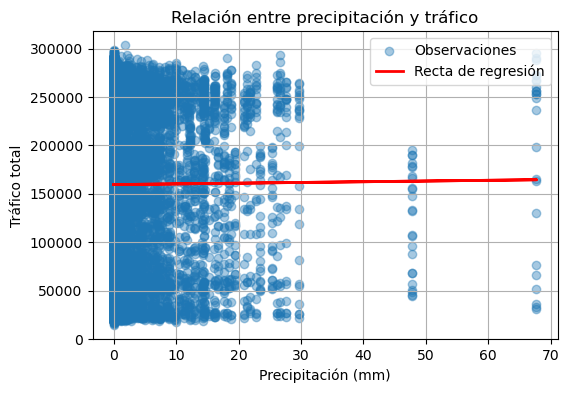

In [16]:
df_final["precipitacion"] = df_final["AEMET_prec"]

# Columnas a excluir
columnas_excluir_fijas = [
    "timestamp", "fecha", "hora", "dia_semana",
    "entre semana", "festivo", "precipitacion"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

columnas_trafico = [
    col for col in df_final.select_dtypes(include="number").columns
    if col not in ["hora", "AEMET_prec"]
]

df_final["trafico_total"] = df_final[columnas_trafico].sum(axis=1)

df_reg = df_final[["trafico_total", "precipitacion"]].dropna()

from sklearn.linear_model import LinearRegression
import numpy as np

X = df_reg[["precipitacion"]]   # debe ser 2D
y = df_reg["trafico_total"]

modelo = LinearRegression()
modelo.fit(X, y)

beta_0 = modelo.intercept_
beta_1 = modelo.coef_[0]

print(f"Intercepto (β0): {beta_0:.2f}")
print(f"Coeficiente precipitación (β1): {beta_1:.2f}")

r2 = modelo.score(X, y)
print(f"R² del modelo: {r2:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Puntos dispersos
plt.scatter(
    X,
    y,
    alpha=0.4,
    color="tab:blue",
    label="Observaciones"
)

# Recta de regresión
plt.plot(
    X,
    modelo.predict(X),
    color="red",
    linewidth=2,
    label="Recta de regresión"
)

plt.xlabel("Precipitación (mm)")
plt.ylabel("Tráfico total")
plt.title("Relación entre precipitación y tráfico")
plt.grid(True)
plt.legend()

# Guardar el gráfico en PNG
plt.savefig(
    "Graficos/correlacion_precipitacion_trafico.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


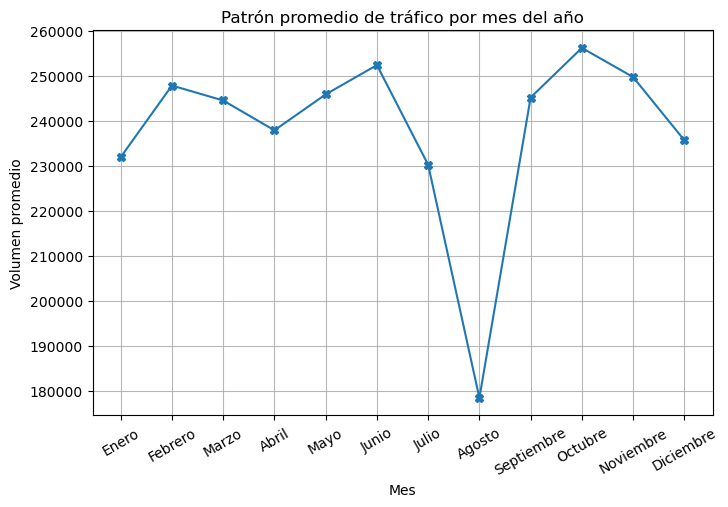

,Mes,Volumen promedio
0,1,231936.821237
1,2,247845.941176
2,3,244522.370968
3,4,237898.759722
4,5,245879.612097
5,6,252388.223611
6,7,230247.110484
7,8,178432.100538
8,9,245183.095833
9,10,256206.475806


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import display

# Asegurar que fecha es datetime
df_final["fecha"] = pd.to_datetime(df_final["fecha"])

# Filtrar solo años completos (y copiar)
df_filtrado = df_final[
    df_final["fecha"].dt.year.isin([2022, 2023, 2024])
].copy()

# 1. Columnas a excluir explícitamente
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo"
]

# 2. Detectar columnas AEMET
columnas_aemet = [col for col in df_filtrado.columns if col.startswith("AEMET")]

# 3. Unir columnas a excluir
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# Crear columna mes
df_filtrado["mes"] = df_filtrado["fecha"].dt.month

# Tráfico promedio por mes del año (solo columnas numéricas)
trafico_mes = (
    df_filtrado
    .drop(columns=columnas_excluir)
    .select_dtypes(include="number")
    .sum(axis=1)
    .groupby(df_filtrado["mes"])
    .mean()
)

# Reordenar meses
trafico_mes = trafico_mes.reindex(range(1, 13))

# 6. Crear carpeta Graficos si no existe
os.makedirs("Graficos", exist_ok=True)

plt.figure(figsize=(8,5))
trafico_mes.plot(kind="line", marker="X")
plt.title("Patrón promedio de tráfico por mes del año")
plt.xlabel("Mes")
plt.ylabel("Volumen promedio")
plt.grid(True, linestyle="-", alpha=0.9)

# Ajuste del eje X: nombres de meses y los 12 visibles
meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

plt.xticks(range(1, 13), meses, rotation=30)

plt.savefig(
    "Graficos/patron_promedio_trafico_por_mes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 9. Tabla asociada
tabla_trafico_mes = pd.DataFrame({
    "Mes": trafico_mes.index,
    "Volumen promedio": trafico_mes.values
}).reset_index(drop=True)

display(tabla_trafico_mes)


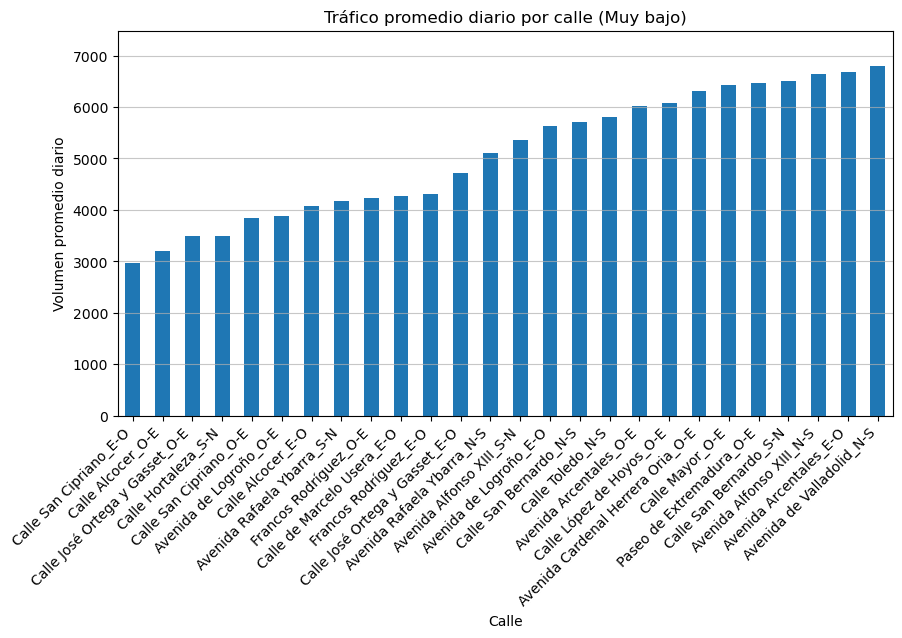

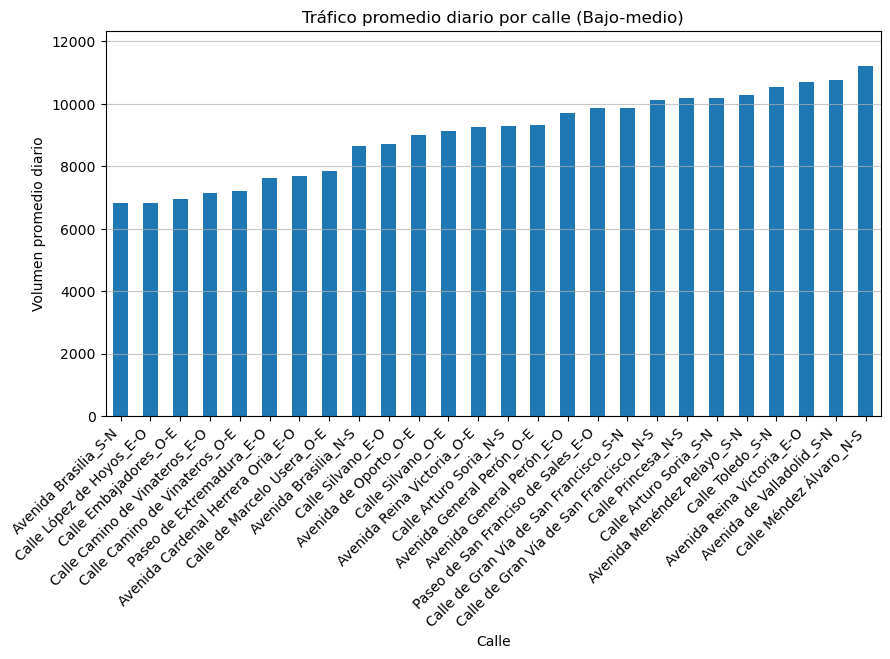

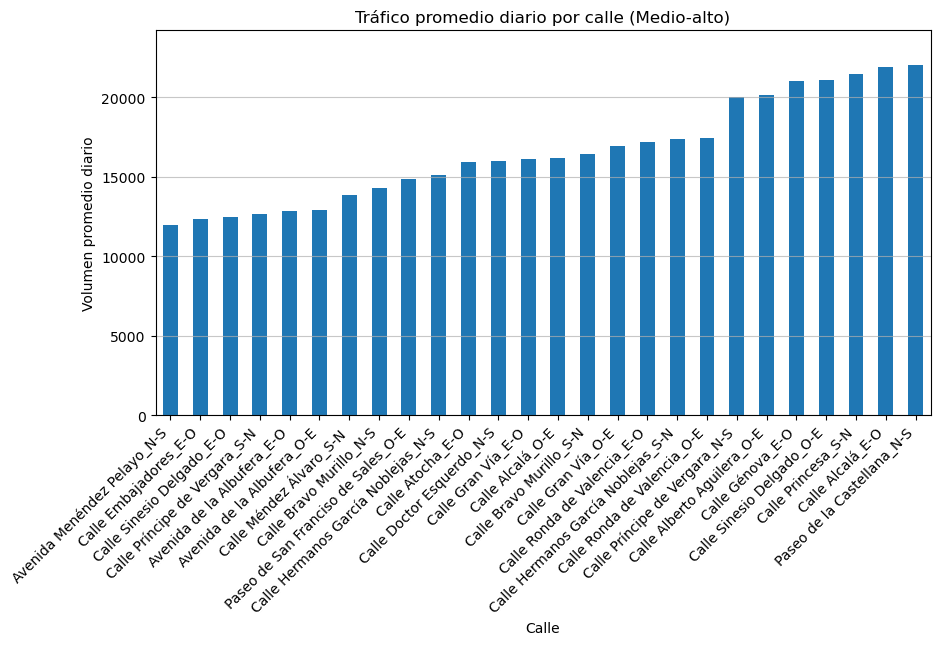

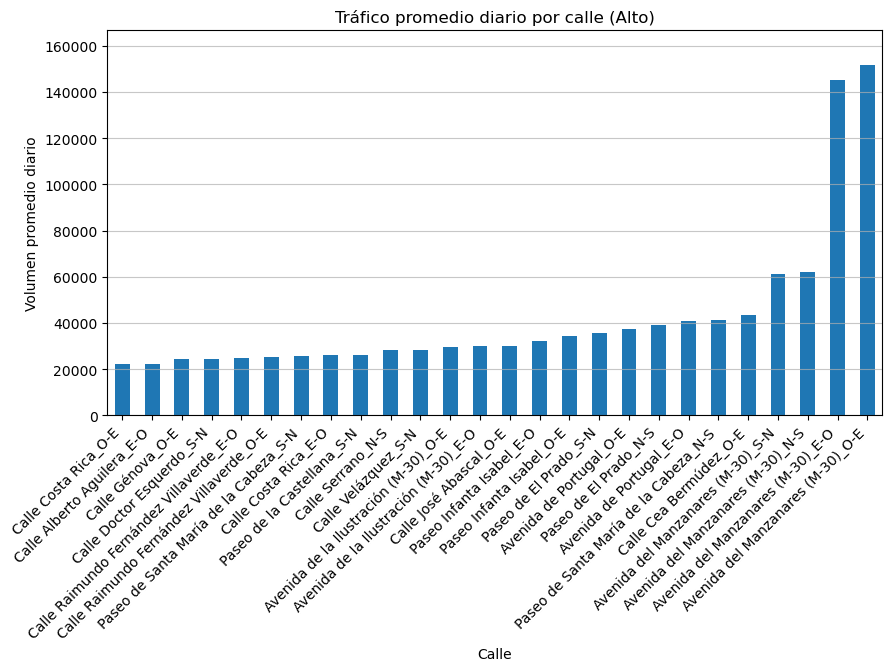

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================================================
# 1. DEFINIR COLUMNAS A EXCLUIR
# =========================================================

columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo",
    "precipitacion",
    "trafico_total"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet


# =========================================================
# 2. IDENTIFICAR COLUMNAS DE TRÁFICO (NUMÉRICAS)
# =========================================================

columnas_trafico = [
    col for col in df_final.columns
    if col not in columnas_excluir
    and pd.api.types.is_numeric_dtype(df_final[col])
]


# =========================================================
# 3. CALCULAR TRÁFICO DIARIO POR CALLE
# =========================================================

trafico_diario = (
    df_final
    .groupby("fecha")[columnas_trafico]
    .sum()
)


# =========================================================
# 4. TRÁFICO PROMEDIO DIARIO POR CALLE
# =========================================================

trafico_medio_calle = trafico_diario.mean()


# =========================================================
# 5. CALCULAR PERCENTILES (25 / 50 / 75)
# =========================================================

p25 = trafico_medio_calle.quantile(0.25)
p50 = trafico_medio_calle.quantile(0.50)
p75 = trafico_medio_calle.quantile(0.75)


# =========================================================
# 6. CLASIFICAR TODAS LAS CALLES EN 4 GRUPOS
# =========================================================

def clasificar_trafico(valor):
    if valor <= p25:
        return "Muy bajo"
    elif valor <= p50:
        return "Bajo-medio"
    elif valor <= p75:
        return "Medio-alto"
    else:
        return "Alto"

grupo_trafico = trafico_medio_calle.apply(clasificar_trafico)


# =========================================================
# 7. CREAR CARPETA PARA LOS GRÁFICOS
# =========================================================

os.makedirs("Graficos", exist_ok=True)


# =========================================================
# 8. FIJAR ESCALA COMÚN PARA TODOS LOS GRÁFICOS
# =========================================================

ylim_max = trafico_medio_calle.max() * 1.05


# =========================================================
# 9. FUNCIÓN PARA GENERAR GRÁFICOS DE BARRAS POR GRUPO
# =========================================================

def grafico_barras_grupo(nombre_grupo):
    datos = trafico_medio_calle[grupo_trafico == nombre_grupo]

    plt.figure(figsize=(10,5))
    datos.sort_values().plot(kind="bar")

    plt.title(f"Tráfico promedio diario por calle ({nombre_grupo})")
    plt.xlabel("Calle")
    plt.ylabel("Volumen promedio diario")
    plt.ylim(0, datos.max() * 1.1)   # ← escala correcta
    plt.grid(axis="y", alpha=0.7)
    plt.xticks(rotation=45, ha="right")

    plt.savefig(
        f"Graficos/trafico_promedio_calles_{nombre_grupo.replace(' ','_').lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# =========================================================
# 10. GENERAR LOS 4 GRÁFICOS (P25 / P50 / P75)
# =========================================================

for grupo in ["Muy bajo", "Bajo-medio", "Medio-alto", "Alto"]:
    grafico_barras_grupo(grupo)


Intercepto (β0): 249027.76
Coeficiente temperatura (β1): -807.95
R² del modelo: 0.000

Función de regresión:
Tráfico = 249027.76 + -807.95 · Temperatura_media


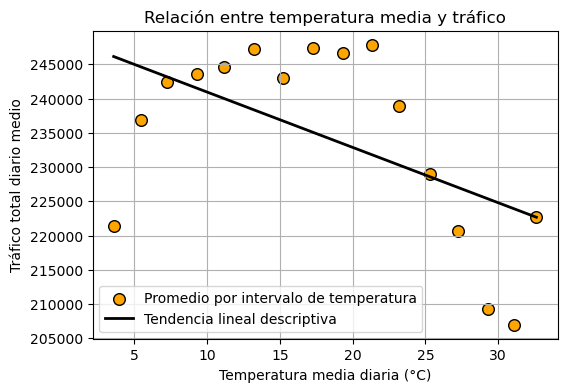

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================================================
# 1. PREPARACIÓN DE DATOS
# =========================================================

# Asegurar formato fecha
df_final["fecha"] = pd.to_datetime(df_final["fecha"])

# Crear variable de trabajo: temperatura media
df_final["temperatura_media"] = df_final["AEMET_tmed"]

# ---------------------------------------------------------
# Columnas a excluir para calcular tráfico
# ---------------------------------------------------------

columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo",
    "temperatura_media"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# ---------------------------------------------------------
# Columnas de tráfico (solo numéricas)
# ---------------------------------------------------------

columnas_trafico = [
    col for col in df_final.columns
    if col not in columnas_excluir
    and pd.api.types.is_numeric_dtype(df_final[col])
]

# ---------------------------------------------------------
# Tráfico total diario
# ---------------------------------------------------------

df_final["trafico_total"] = df_final[columnas_trafico].sum(axis=1)

# Dataset limpio para análisis
df_reg = df_final[["temperatura_media", "trafico_total"]].dropna().copy()

# =========================================================
# 2. BINNING DE TEMPERATURA (REDUCIR RUIDO VISUAL)
# =========================================================

# Crear intervalos de temperatura (2 ºC)
bins = np.arange(
    df_reg["temperatura_media"].min(),
    df_reg["temperatura_media"].max() + 2,
    2
)

df_reg["temp_bin"] = pd.cut(df_reg["temperatura_media"], bins)

# Tráfico medio por intervalo
df_binned = (
    df_reg
    .groupby("temp_bin", observed=True)
    .agg({
        "temperatura_media": "mean",
        "trafico_total": "mean"
    })
)

# =========================================================
# 3. MODELO DE REGRESIÓN LINEAL
# =========================================================

X = df_binned[["temperatura_media"]]   # variable explicativa
y = df_binned["trafico_total"]         # variable respuesta

# Ajuste lineal descriptivo (mínimos cuadrados)
beta_1, beta_0 = np.polyfit(
    df_binned["temperatura_media"],
    df_binned["trafico_total"],
    1
)

# Valores de la recta
x_linea = df_binned["temperatura_media"]
y_linea = beta_1 * x_linea + beta_0

print(f"Intercepto (β0): {beta_0:.2f}")
print(f"Coeficiente temperatura (β1): {beta_1:.2f}")
print(f"R² del modelo: {r2:.3f}")

print(
    f"\nFunción de regresión:\n"
    f"Tráfico = {beta_0:.2f} + {beta_1:.2f} · Temperatura_media"
)

# =========================================================
# 4. GRÁFICO: PROMEDIOS POR BIN + RECTA
# =========================================================

os.makedirs("Graficos", exist_ok=True)

plt.figure(figsize=(6,4))

# Puntos medios por intervalo
plt.scatter(
    df_binned["temperatura_media"],
    df_binned["trafico_total"],
    color="orange",
    edgecolor="black",
    s=70,
    label="Promedio por intervalo de temperatura"
)

# Recta descriptiva
plt.plot(
    x_linea,
    y_linea,
    color="black",
    linewidth=2,
    label="Tendencia lineal descriptiva"
)

plt.xlabel("Temperatura media diaria (°C)")
plt.ylabel("Tráfico total diario medio")
plt.title("Relación entre temperatura media y tráfico")
plt.grid(True)
plt.legend()

plt.savefig(
    "Graficos/correlacion_temperatura_trafico_binned.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Intercepto (β0): 309846.32
Coeficiente precipitación (β1): 267.49
R² del modelo: 0.017

Función de regresión:
Tráfico = 309846.32 + 267.49 · Precipitación


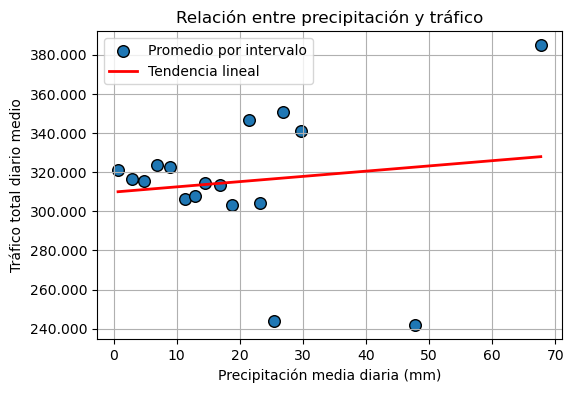

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

# =========================================================
# 1. PREPARACIÓN DE DATOS
# =========================================================

# Variable de precipitación
df_final["precipitacion"] = df_final["AEMET_prec"]

# Columnas a excluir para calcular tráfico
columnas_excluir_fijas = [
    "timestamp",
    "fecha",
    "hora",
    "dia_semana",
    "entre semana",
    "festivo",
    "precipitacion"
]

columnas_aemet = [col for col in df_final.columns if col.startswith("AEMET")]
columnas_excluir = columnas_excluir_fijas + columnas_aemet

# Columnas de tráfico (solo numéricas)
columnas_trafico = [
    col for col in df_final.columns
    if col not in columnas_excluir
    and pd.api.types.is_numeric_dtype(df_final[col])
]

# Tráfico total diario
df_final["trafico_total"] = df_final[columnas_trafico].sum(axis=1)

# Dataset para análisis
df_reg = df_final[["precipitacion", "trafico_total"]].dropna().copy()

# =========================================================
# 2. BINNING DE PRECIPITACIÓN
# =========================================================

# Intervalos de precipitación (por ejemplo, cada 2 mm)
bins = np.arange(
    df_reg["precipitacion"].min(),
    df_reg["precipitacion"].max() + 2,
    2
)

df_reg["prec_bin"] = pd.cut(df_reg["precipitacion"], bins)

# Tráfico medio por intervalo
df_binned = (
    df_reg
    .groupby("prec_bin", observed=True)
    .agg({
        "precipitacion": "mean",
        "trafico_total": "mean"
    })
)

# =========================================================
# 3. MODELO DE REGRESIÓN LINEAL
# =========================================================

X = df_binned[["precipitacion"]]
y = df_binned["trafico_total"]

modelo = LinearRegression()
modelo.fit(X, y)

beta_0 = modelo.intercept_
beta_1 = modelo.coef_[0]
r2 = modelo.score(X, y)

print(f"Intercepto (β0): {beta_0:.2f}")
print(f"Coeficiente precipitación (β1): {beta_1:.2f}")
print(f"R² del modelo: {r2:.3f}")

print(
    f"\nFunción de regresión:\n"
    f"Tráfico = {beta_0:.2f} + {beta_1:.2f} · Precipitación"
)

# =========================================================
# 4. GRÁFICO: PROMEDIOS POR BIN + RECTA
# =========================================================

os.makedirs("Graficos", exist_ok=True)

# Gráfico
plt.figure(figsize=(6,4))

plt.scatter(
    X,
    y,
    color="tab:blue",
    edgecolor="black",
    s=70,
    label="Promedio por intervalo"
)

plt.plot(
    X,
    modelo.predict(X),
    color="red",
    linewidth=2,
    label="Tendencia lineal"
)

plt.xlabel("Precipitación media diaria (mm)")
plt.ylabel("Tráfico total diario medio")
plt.title("Relación entre precipitación y tráfico")
plt.grid(True)
plt.legend()

# 🔧 EVITAR NOTACIÓN CIENTÍFICA
plt.ticklabel_format(style="plain", axis="y")

# 🔧 FORMATO LEGIBLE (opcional)
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

plt.savefig(
    "Graficos/correlacion_precipitacion_trafico_binned.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



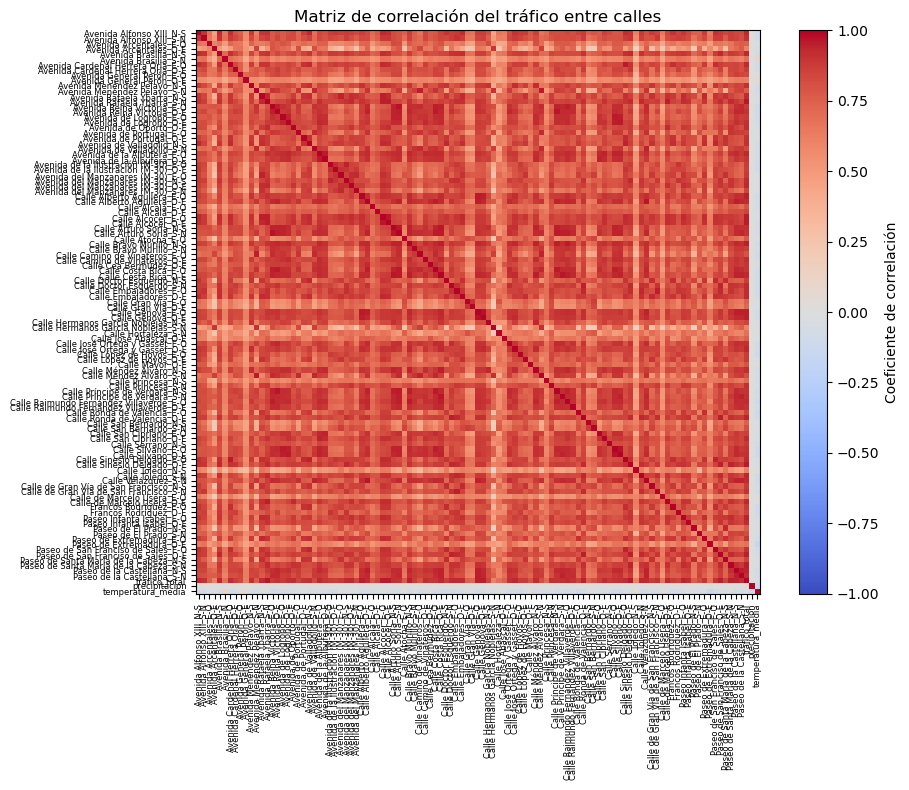

In [23]:
columnas_trafico = [
    col for col in df_final.columns
    if pd.api.types.is_numeric_dtype(df_final[col])
    and not col.startswith("AEMET")
    and col not in ["hora"]
]

df_corr = df_final[columnas_trafico].corr(method="pearson")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(df_corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Coeficiente de correlación")

plt.xticks(
    ticks=range(len(df_corr.columns)),
    labels=df_corr.columns,
    rotation=90,
    fontsize=6
)

plt.yticks(
    ticks=range(len(df_corr.index)),
    labels=df_corr.index,
    fontsize=6
)

plt.savefig(
    "Graficos/correlacion_calles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.title("Matriz de correlación del tráfico entre calles")
plt.tight_layout()
plt.show()

top_calles = (
    df_final[columnas_trafico]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)

df_corr_top = df_final[top_calles].corr()


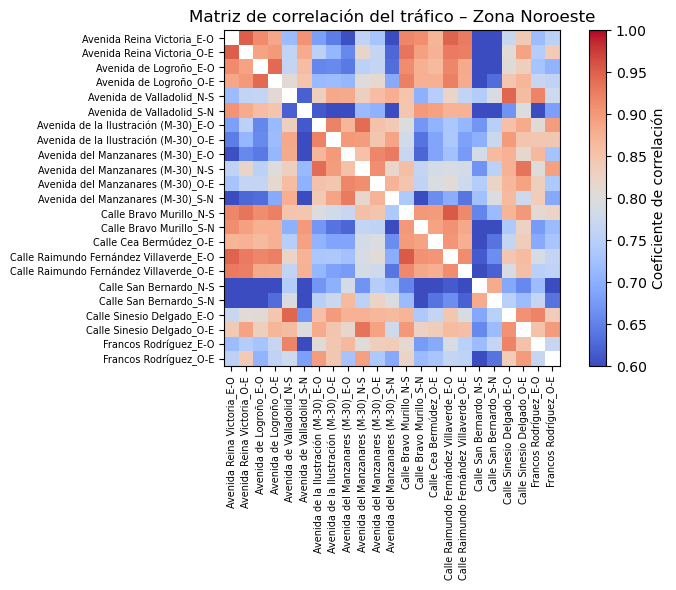

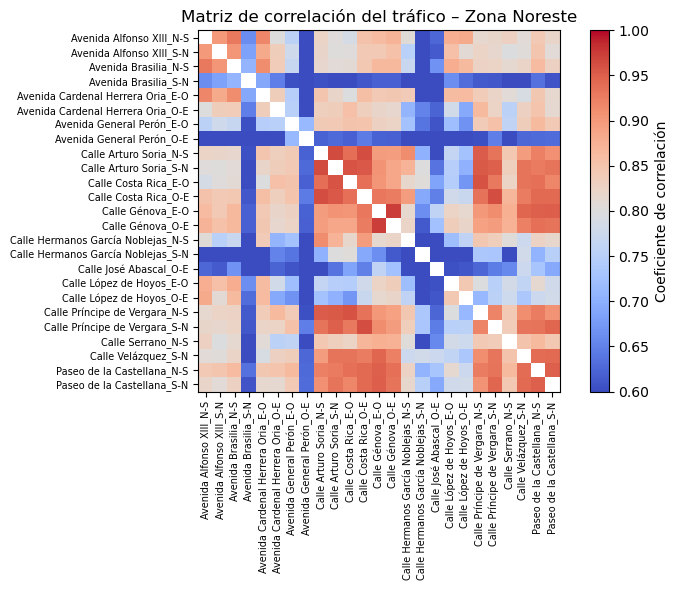

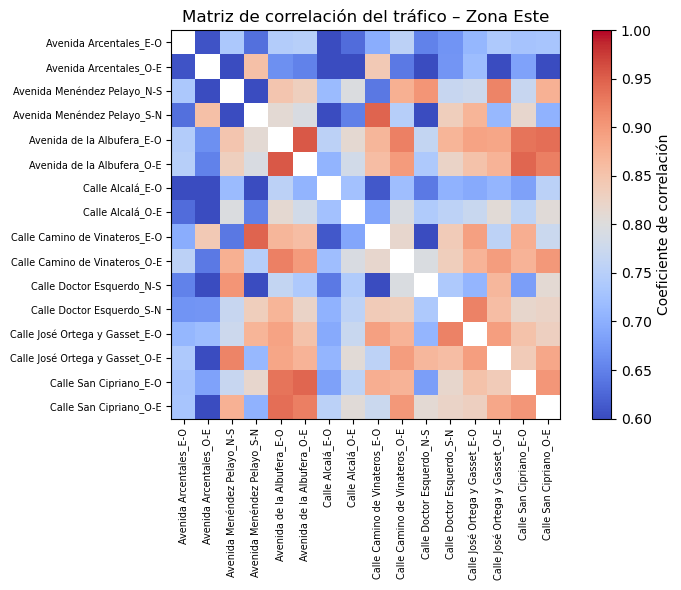

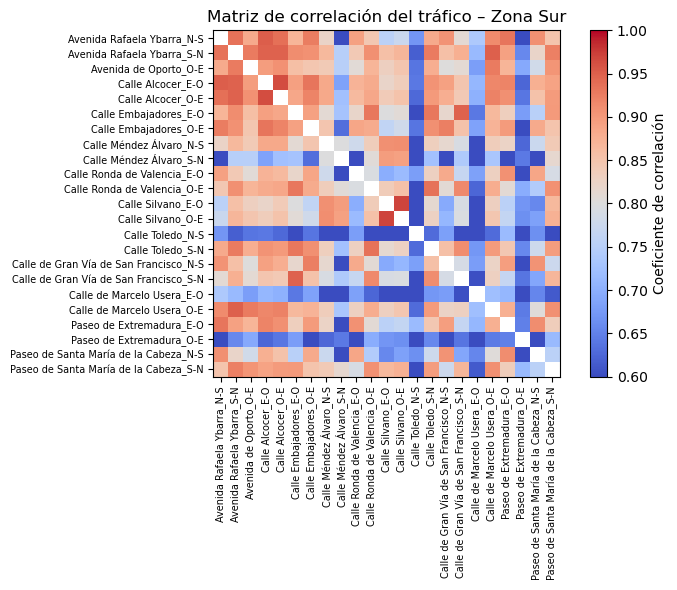

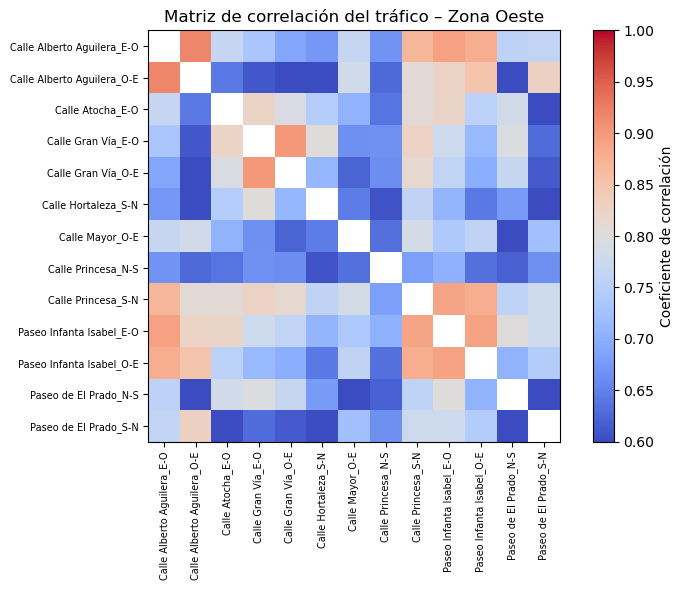

In [27]:
zonas_calles = {
    "Noroeste": [
        "Avenida de la Ilustración (M-30)",
        "Avenida del Manzanares (M-30)",
        "Avenida de Valladolid",
        "Avenida de Logroño",
        "Avenida Reina Victoria",
        "Calle Bravo Murillo",
        "Calle Cea Bermúdez",
        "Calle Raimundo Fernández Villaverde",
        "Calle San Bernardo",
        "Calle Sinesio Delgado",
        "Francos Rodríguez",
        "Paseo de San Francisco de Sales",
    ],
    "Noreste": [
        "Avenida Cardenal Herrera Oria",
        "Avenida Alfonso XIII",
        "Avenida Brasilia",
        "Avenida General Perón",
        "Calle Arturo Soria",
        "Calle Costa Rica",
        "Calle Génova",
        "Calle Hermanos García Noblejas",
        "Calle José Abascal",
        "Calle López de Hoyos",
        "Calle Príncipe de Vergara",
        "Calle Serrano",
        "Calle Velázquez",
        "Paseo de la Castellana",
    ],
    "Este": [
        "Avenida Arcentales",
        "Avenida Menéndez Pelayo",
        "Avenida de la Albufera",
        "Calle Alcalá",
        "Calle Camino de Vinateros",
        "Calle Doctor Esquerdo",
        "Calle José Ortega y Gasset",
        "Calle San Cipriano"

    ],
    "Sur": [
        "Avenida Rafaela Ybarra",
        "Avenida de Oporto",
        "Calle Alcocer",
        "Calle Embajadores",
        "Calle Méndez Álvaro",
        "Calle Ronda de Valencia",
        "Calle Silvano",
        "Calle Toledo",
        "Calle de Gran Vía de San Francisco",
        "Calle de Marcelo Usera",
        "Paseo de Extremadura",
        "Paseo de Santa María de la Cabeza"

    ],
    "Oeste": [
        "Calle Alberto Aguilera",
        "Calle Atocha",
        "Calle Gran Vía",
        "Calle Hortaleza",
        "Calle Mayor",
        "Calle Princesa",
        "Paseo Infanta Isabel",
        "Paseo de El Prado"

    ]
}

def columnas_por_zona(columnas_trafico, calles_zona):
    cols = []
    for col in columnas_trafico:
        nombre_base = col.split("_")[0]
        if nombre_base in calles_zona:
            cols.append(col)
    return cols

import matplotlib.pyplot as plt
import numpy as np

def heatmap_correlacion(df, columnas, titulo):
    corr = df[columnas].corr()

    # eliminar diagonal
    np.fill_diagonal(corr.values, np.nan)

    plt.figure(figsize=(8, 6))
    plt.imshow(
        corr,
        cmap="coolwarm",
        vmin=0.6,
        vmax=1.0
    )
    plt.colorbar(label="Coeficiente de correlación")

    plt.xticks(
        range(len(corr.columns)),
        corr.columns,
        rotation=90,
        fontsize=7
    )
    plt.yticks(
        range(len(corr.index)),
        corr.index,
        fontsize=7
    )

    plt.title(titulo)
    plt.tight_layout()

    plt.savefig(
        f"Graficos/correlacion_trafico_zona_{zona.replace(' ', '_').lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


for zona, calles in zonas_calles.items():
    cols_zona = columnas_por_zona(columnas_trafico, calles)

    # Evitar zonas con muy pocas calles
    if len(cols_zona) < 2:
        continue

    heatmap_correlacion(
        df_final,
        cols_zona,
        f"Matriz de correlación del tráfico – Zona {zona}"
    )

    
